In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\Lenovo\Documents\Notes\APRIL\22nd- Cross validation\car_evaluation.csv")
data

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [3]:
data.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
data.describe()

,vhigh,vhigh.1,2,2.1,small,low,unacc
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [5]:
data.isnull().sum()

vhigh      0
vhigh.1    0
2          0
2.1        0
small      0
low        0
unacc      0
dtype: int64

In [6]:
data.shape

(1727, 7)

In [7]:
col_names=['buying','maint','doors','persons','lug_boot','safety','class']
data.columns=col_names

In [8]:
data.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')

In [9]:
data.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [11]:
col_names=['buying','maint','doors','persons','lug_boot','safety','class']
for col in col_names:
    print(data[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [12]:
data['class'].value_counts()

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [13]:
x = data.drop(['class'], axis=1)
y = data['class']

In [119]:
x.head()

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,med
1,vhigh,vhigh,2,2,small,high
2,vhigh,vhigh,2,2,med,low
3,vhigh,vhigh,2,2,med,med
4,vhigh,vhigh,2,2,med,high


In [121]:
y.head()

0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: class, dtype: object

In [173]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [175]:
x_train.shape,x_test.shape

((1381, 6), (346, 6))

In [177]:
y_train.shape,y_test.shape

((1381,), (346,))

In [179]:
x_train.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
dtype: object

In [181]:
x_train.head()

,buying,maint,doors,persons,lug_boot,safety
1648,low,low,3,2,small,high
1465,low,high,4,2,big,high
361,vhigh,low,3,4,small,high
315,vhigh,med,5more,more,small,med
1372,low,vhigh,4,more,med,high


In [183]:
print(x_train.columns)

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'], dtype='object')


In [185]:
print(x.columns)

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'], dtype='object')


In [198]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in x.columns:
    x[col] = le.fit_transform(x[col])

In [211]:
import category_encoders as ce

In [213]:
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])
x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)

In [215]:
x_train.head()

,buying,maint,doors,persons,lug_boot,safety
1648,1,1,1,1,1,1
1465,1,2,2,1,2,1
361,2,1,1,2,1,1
315,2,3,3,3,1,2
1372,1,4,2,3,3,1


In [217]:
x_test.head()

,buying,maint,doors,persons,lug_boot,safety
1318,1,4,4,3,3,1
124,2,2,4,2,2,1
648,3,3,4,1,1,2
249,2,3,1,1,2,2
1598,1,3,3,1,2,3


# decision tree classifier with gini index:

In [219]:
print(x_train.shape)  
print(y_train.shape)  

(1381, 6)
(1381,)


In [221]:
from sklearn.tree import DecisionTreeClassifier

In [225]:
gini=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)
gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [227]:
y_pred=gini.predict(x_test)

In [229]:
from sklearn.metrics import accuracy_score
ac=accuracy_score(y_test,y_pred)
ac

0.7890173410404624

In [231]:
y_pred_train=gini.predict(x_train)
y_pred_train

array(['unacc', 'unacc', 'acc', ..., 'unacc', 'acc', 'acc'], dtype=object)

In [233]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.8096


In [235]:
print('Training set score: {:.4f}'.format(gini.score(x_train, y_train)))
print('Test set score: {:.4f}'.format(gini.score(x_test, y_test)))

Training set score: 0.8096
Test set score: 0.7890


[Text(0.4, 0.875, 'x[3] <= 1.5\ngini = 0.454\nsamples = 1381\nvalue = [307, 55, 970, 49]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 463\nvalue = [0, 0, 463, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[5] <= 2.5\ngini = 0.577\nsamples = 918\nvalue = [307.0, 55.0, 507.0, 49.0]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[1] <= 3.5\ngini = 0.627\nsamples = 616\nvalue = [307, 55, 205, 49]'),
 Text(0.2, 0.125, 'gini = 0.623\nsamples = 464\nvalue = [254, 55, 106, 49]'),
 Text(0.6, 0.125, 'gini = 0.454\nsamples = 152\nvalue = [53.0, 0.0, 99.0, 0.0]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 302\nvalue = [0, 0, 302, 0]')]

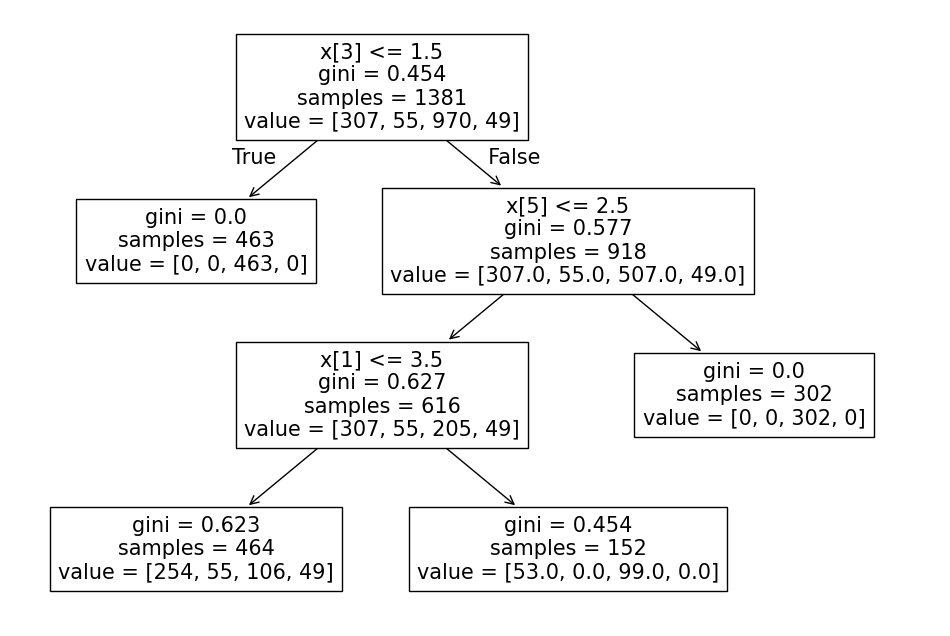

In [237]:
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(gini.fit(x_train, y_train)) 

In [280]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [281]:
import graphviz 
dot_data = tree.export_graphviz(gini, out_file=None, 
                              feature_names=x_train.columns,  
                              class_names=y_train,  
                              filled=True, rounded=True,  
                              special_characters=True)

graph = graphviz.Source(dot_data) 
graph 

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [282]:
en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


# fit the model
en.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [283]:
y_pred_en = en.predict(x_test)

In [284]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.7890


In [290]:
y_pred_train_en = en.predict(x_train)
y_pred_train_en

array(['unacc', 'unacc', 'acc', ..., 'unacc', 'acc', 'acc'], dtype=object)

In [292]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.8096


In [294]:
print('Training set score: {:.4f}'.format(en.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(en.score(x_test, y_test)))

Training set score: 0.8096
Test set score: 0.7890


[Text(0.4, 0.875, 'x[3] <= 1.5\nentropy = 1.196\nsamples = 1381\nvalue = [307, 55, 970, 49]'),
 Text(0.2, 0.625, 'entropy = 0.0\nsamples = 463\nvalue = [0, 0, 463, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[5] <= 2.5\nentropy = 1.47\nsamples = 918\nvalue = [307.0, 55.0, 507.0, 49.0]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[1] <= 3.5\nentropy = 1.631\nsamples = 616\nvalue = [307, 55, 205, 49]'),
 Text(0.2, 0.125, 'entropy = 1.67\nsamples = 464\nvalue = [254, 55, 106, 49]'),
 Text(0.6, 0.125, 'entropy = 0.933\nsamples = 152\nvalue = [53.0, 0.0, 99.0, 0.0]'),
 Text(0.8, 0.375, 'entropy = 0.0\nsamples = 302\nvalue = [0, 0, 302, 0]')]

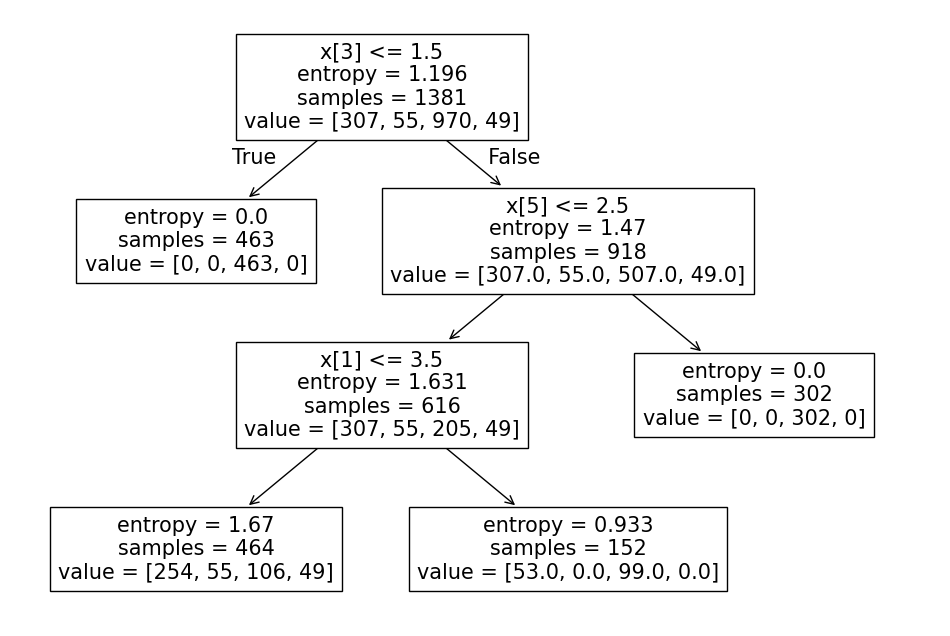

In [296]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(en.fit(x_train, y_train))

In [297]:
import graphviz 
dot_data = tree.export_graphviz(en, out_file=None, 
                              feature_names=x_train.columns,  
                              class_names=y_train,  
                              filled=True, rounded=True,  
                              special_characters=True)

graph = graphviz.Source(dot_data) 

graph 

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [298]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_en)
cm

array([[ 58,   0,  19,   0],
       [ 14,   0,   0,   0],
       [ 24,   0, 215,   0],
       [ 16,   0,   0,   0]], dtype=int64)

In [300]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

         acc       0.52      0.75      0.61        77
        good       0.00      0.00      0.00        14
       unacc       0.92      0.90      0.91       239
       vgood       0.00      0.00      0.00        16

    accuracy                           0.79       346
   macro avg       0.36      0.41      0.38       346
weighted avg       0.75      0.79      0.76       346



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
